# Loading REAM strips over Flask Glacier. 
Adapted from https://pdemtools.readthedocs.io/en/v1.2.2/examples/strip_search.html See that page for more details and nice ways of handling the files once downloaded, etc. 

In [7]:
import pdemtools as pdt
import matplotlib.pyplot as plt

## Download the metadata for the strips that intersect a bounding box over Flask Glacier.

In [33]:
bounds = (-2372713.1151084295,1223461.1793956908,-2369204.73989194,1226304.5892606715)     # a bounding box over Flask Glacier, copied from the boundingbox plugin in qgis

gdf = pdt.search(
    dataset='rema',
    bounds = bounds,
    # dates = '20241201/20260131',
    # months = [6,7,8,9],
    #years = [2020,2026],
    # baseline_max_hours = 24,
    sensors=['WV03', 'WV02', 'WV01'],
    accuracy=2,
    min_aoi_frac = 0.7,
)

print(f'{len(gdf)} strips found')



16 strips found


## Print info on the strips we found above

In [34]:
gdf[['pdt_id', 'pdt_datetime1', 'pdt_datetime2']]

,pdt_id,pdt_datetime1,pdt_datetime2
0,SETSM_s2s041_W1W2_20120224_10200100189A3800_10...,2012-02-24 13:50:23+00:00,2012-02-24 14:06:51+00:00
1,SETSM_s2s041_WV01_20130222_1020010020A1AC00_10...,2013-02-22 13:06:08+00:00,2013-02-22 13:07:02+00:00
2,SETSM_s2s041_WV02_20130305_10300100203A2100_10...,2013-03-05 13:30:37+00:00,2013-03-05 13:31:49+00:00
3,SETSM_s2s041_WV01_20160119_10200100473C9700_10...,2016-01-19 15:45:20+00:00,2016-01-19 15:46:26+00:00
4,SETSM_s2s041_WV01_20160831_1020010053485200_10...,2016-08-31 16:33:23+00:00,2016-08-31 16:34:18+00:00
5,SETSM_s2s041_WV01_20170302_102001005D619400_10...,2017-03-02 16:52:43+00:00,2017-03-02 16:53:50+00:00
6,SETSM_s2s041_WV02_20180309_103001007A015B00_10...,2018-03-09 13:59:11+00:00,2018-03-09 14:00:29+00:00
7,SETSM_s2s041_WV01_20190408_102001008486B700_10...,2019-04-08 16:45:45+00:00,2019-04-08 16:46:32+00:00
8,SETSM_s2s041_WV01_20190417_1020010084640100_10...,2019-04-17 16:33:55+00:00,2019-04-17 16:35:03+00:00
9,SETSM_s2s041_WV01_20200221_1020010095CD6000_10...,2020-02-21 16:55:01+00:00,2020-02-21 16:55:46+00:00


## Display a preview of one of the strips

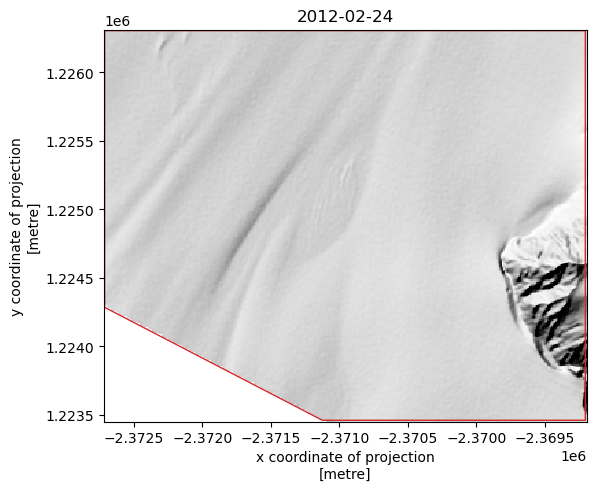

In [35]:
i = 0

preview = pdt.load.preview(gdf.iloc[[i]], bounds)

fig, ax = plt.subplots(layout='constrained')
preview.plot.imshow(cmap='Greys_r', add_colorbar=False)

gdf.iloc[[i]].plot(ax=ax, fc='none', ec='tab:red')

ax.set_title(gdf.iloc[[i]].pdt_datetime1.dt.date.values[0])
plt.show()



## Download one of the strips, cropping to the bounding box deifned above

In [36]:
dem = pdt.load.from_search(gdf.iloc[[i]], bounds,)

In [37]:
dem

<xarray.DataArray (y: 1423, x: 1755)> Size: 10MB
array([[414.     , 414.0078 , 414.03125, ..., 440.75   , 440.91406,
        441.07812],
       [414.     , 414.01562, 414.03125, ..., 440.73438, 440.90625,
        441.08594],
       [414.0078 , 414.01562, 414.03125, ..., 440.71875, 440.90625,
        441.09375],
       ...,
       [      nan,       nan,       nan, ..., 469.97656, 470.10938,
        470.25   ],
       [      nan,       nan,       nan, ..., 469.95312, 470.08594,
        470.22656],
       [      nan,       nan,       nan, ..., 469.9375 , 470.0703 ,
        470.21094]], shape=(1423, 1755), dtype=float32)
Coordinates:
  * x            (x) float64 14kB -2.373e+06 -2.373e+06 ... -2.369e+06
  * y            (y) float64 11kB 1.226e+06 1.226e+06 ... 1.223e+06 1.223e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     -9999.0

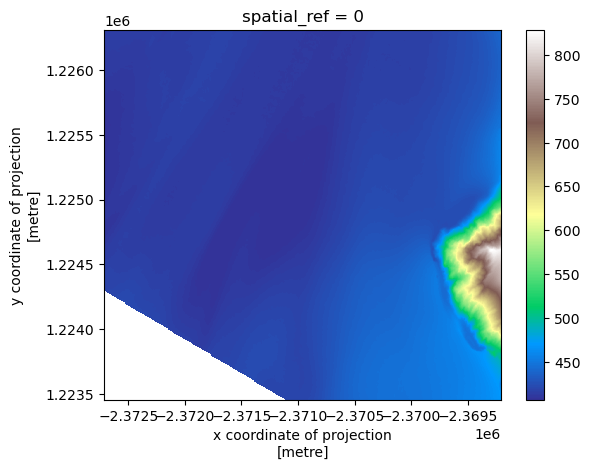

In [38]:
dem.plot.imshow(cmap='terrain', add_colorbar=True)

## Save to disk for use again later

In [ ]:
dem.rio.to_raster('test.tif')

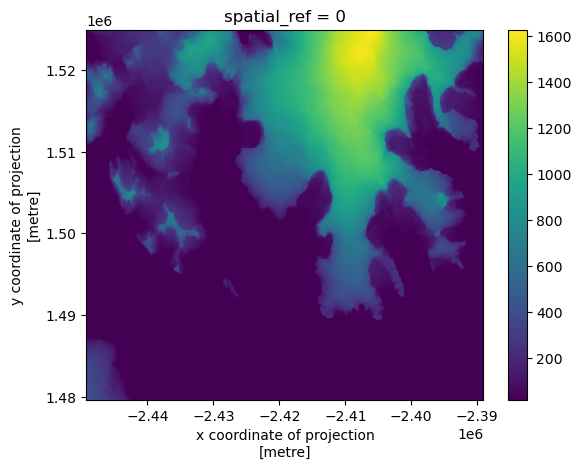

In [3]:
bounds = [-2449219.2785471,1479670.5186804049,-2389103.576101275,1524880.2818127396]
dem = pdt.load.mosaic(
    dataset='rema',  # must be `arcticdem` or `rema`
    resolution=32,        # must be 2, 10, or 32
    bounds=bounds,        # (xmin, ymin, xmax, ymax) or a shapely geometry
)

dem.plot()
dem.rio.to_raster('/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/worldview/rema_mosaic/JRI.tif')